## Problem 2

<div style="text-align:center;">
    <img src="Problem2.png" width=600">
</div>

### Part 1

In [66]:
def cross_matrix(vec):
    
    return np.array([[0, -vec[2], vec[1]],
                      [vec[2], 0, -vec[0]],
                      [-vec[1], vec[0], 0]])

### Part 2

In [67]:
def uncross_matrix(mat):
    
    return np.array([[mat[2,1]],
                      [mat[0,2]], 
                      [-mat[0,1]]])

### Part 3

In [68]:
def omega_dot(t, omega, I_B):
    skew_omega = cross_matrix(omega)
    return -np.linalg.inv(I_B) @ (skew_omega @ I_B @ omega)

### Part 4

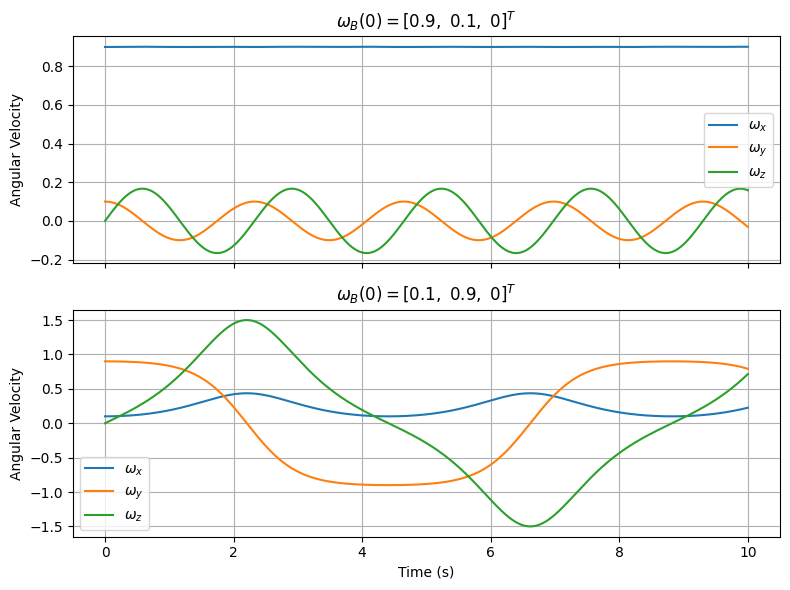

In [69]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

omega0 = np.array([0.1,0.9,0])
I_B = np.array([[10, 0, 0],
                [0,  5, 0],
                [0,  0, 1]], dtype=float)

# Simulation time 10 seconds
time = np.linspace(0,10,1000)

# Initial Conditions
omega0_a = np.array([0.9,0.1,0.0])
omega0_b = np.array([0.1,0.9,0.0])

sol_a = solve_ivp(lambda t,y: omega_dot(t,y,I_B),
                  [0,10], omega0_a,
                  t_eval=time, atol=1e-8, rtol=1e-8)

sol_b = solve_ivp(lambda t,y: omega_dot(t,y,I_B),
                  [0,10], omega0_b,
                  t_eval=time, atol=1e-8, rtol=1e-8)

# Create subplots
fig, ax = plt.subplots(2, 1, figsize=(8,6), sharex=True)

# ---- First initial condition ----
ax[0].plot(sol_a.t, sol_a.y[0], label=r'$\omega_x$')
ax[0].plot(sol_a.t, sol_a.y[1], label=r'$\omega_y$')
ax[0].plot(sol_a.t, sol_a.y[2], label=r'$\omega_z$')

ax[0].set_title(r'$\omega_B(0)=[0.9,\ 0.1,\ 0]^T$')
ax[0].set_ylabel('Angular Velocity')
ax[0].grid(True)
ax[0].legend()

# ---- Second initial condition ----
ax[1].plot(sol_b.t, sol_b.y[0], label=r'$\omega_x$')
ax[1].plot(sol_b.t, sol_b.y[1], label=r'$\omega_y$')
ax[1].plot(sol_b.t, sol_b.y[2], label=r'$\omega_z$')

ax[1].set_title(r'$\omega_B(0)=[0.1,\ 0.9,\ 0]^T$')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Angular Velocity')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

### Part 5

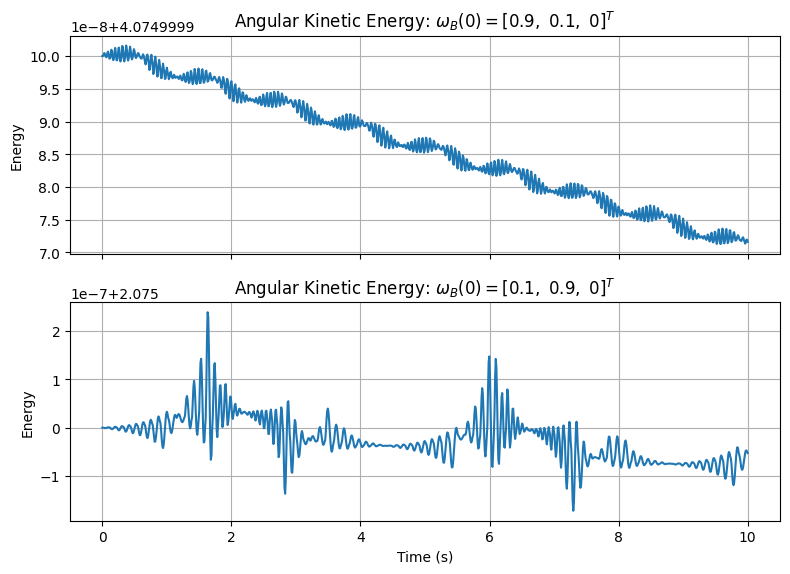

In [70]:
# Angular kinetic energy function
def kinetic_energy(omega, I_B):
    return 0.5 * omega.T @ I_B @ omega

# 
energy_a = np.array([kinetic_energy(sol_a.y[:, i], I_B) for i in range(len(sol_a.t))])
energy_b = np.array([kinetic_energy(sol_b.y[:, i], I_B) for i in range(len(sol_b.t))])

# plot both cases as subplots
fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax[0].plot(sol_a.t, energy_a)
ax[0].set_title(r'Angular Kinetic Energy: $\omega_B(0)=[0.9,\ 0.1,\ 0]^T$')
ax[0].set_ylabel('Energy')
ax[0].grid(True)

ax[1].plot(sol_b.t, energy_b)
ax[1].set_title(r'Angular Kinetic Energy: $\omega_B(0)=[0.1,\ 0.9,\ 0]^T$')
ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Energy')
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Problem 3

<div style="text-align:center;">
    <img src="Problem3.png" width="600">
</div>

### Part 1

The system of the simple hopper has a 2D rigid-body which has 2-links,the second link has its own angle and a variable length. Therefore, we need 5 variables in order to fully defined the motion of the system

In [71]:
import sympy as sp

# Configuration variables
x, y = sp.symbols('x y', real=True)          
theta, phi = sp.symbols('theta phi', real=True)  
l = sp.symbols('l', real=True)           

# Full configuration vector q
q = sp.Matrix([x, y, theta, phi, l])

# Pose variables
pose = sp.Matrix([x, y, theta])

# Shape variables
shape = sp.Matrix([phi, l])

In [72]:
print('Configuration variables q:')
q

Configuration variables q:


⎡x⎤
⎢ ⎥
⎢y⎥
⎢ ⎥
⎢θ⎥
⎢ ⎥
⎢φ⎥
⎢ ⎥
⎣l⎦

In [73]:
print('Pose variables:')
pose

Pose variables:


⎡x⎤
⎢ ⎥
⎢y⎥
⎢ ⎥
⎣θ⎦

In [74]:
print('Shape variables:')
shape

Shape variables:


⎡φ⎤
⎢ ⎥
⎣l⎦

### Part 2

Since the hopper has 5 configuration variables (x,y,θ,ϕ,l), the mass matrix has dimension 5×5.

### Part 3

In [75]:
import sympy as sp

# Time
t = sp.symbols('t', real=True)

# Constants
m1, m2, w = sp.symbols('m1 m2 w', real=True)

# Configuration variables as a function of time
x = sp.Function('x')(t)
y = sp.Function('y')(t)
theta = sp.Function('theta')(t)
phi = sp.Function('phi')(t)
l = sp.Function('l')(t)

# Positions of the masses
p_m1_right = sp.Matrix([
    x + w*sp.cos(theta),
    y + w*sp.sin(theta)
])

p_m1_left = sp.Matrix([
    x - w*sp.cos(theta),
    y - w*sp.sin(theta)
])

p_m2 = sp.Matrix([
    x + l*sp.cos(phi),
    y + l*sp.sin(phi)
])

# Velocities
v_m1_right = sp.diff(p_m1_right, t)
v_m1_left  = sp.diff(p_m1_left, t)
v_m2       = sp.diff(p_m2, t)

# Kinetic energy
T = sp.Rational(1,2)*m1*v_m1_right.dot(v_m1_right) \
  + sp.Rational(1,2)*m1*v_m1_left.dot(v_m1_left) \
  + sp.Rational(1,2)*m2*v_m2.dot(v_m2)

T = sp.simplify(sp.expand(T))

print("Kinetic Energy T:")
T

Kinetic Energy T:


### Part 4

In [76]:
import sympy as sp

# Time
t = sp.symbols('t', real=True)

# Constants
m1, m2, w, g = sp.symbols('m1 m2 w g', real=True)

# Configuration variables
x = sp.Function('x')(t)
y = sp.Function('y')(t)
theta = sp.Function('theta')(t)
phi = sp.Function('phi')(t)
l = sp.Function('l')(t)

# Positions
p_m1_right = sp.Matrix([
    x + w*sp.cos(theta),
    y + w*sp.sin(theta)
])

p_m1_left = sp.Matrix([
    x - w*sp.cos(theta),
    y - w*sp.sin(theta)
])

p_m2 = sp.Matrix([
    x + l*sp.cos(phi),
    y + l*sp.sin(phi)
])

# Potential energy = m*g*height
V = m1*g*p_m1_right[1] + m1*g*p_m1_left[1] + m2*g*p_m2[1]

V = sp.simplify(sp.expand(V))

print("Potential Energy V:")
V

Potential Energy V:


### Part 5

In [77]:
import sympy as sp

# Variables & Constants
t = sp.symbols('t', real=True)

m1, m2, w, g = sp.symbols('m1 m2 w g', real=True)

x = sp.Function('x')(t)
y = sp.Function('y')(t)
theta = sp.Function('theta')(t)
phi = sp.Function('phi')(t)
l = sp.Function('l')(t)

# Configuration variables
q = sp.Matrix([x, y, theta, phi, l])
qd = q.diff(t)

# Inputs
tau_phi = sp.Function('tau_phi')(t)
tau_l = sp.Function('tau_l')(t)

Q = sp.Matrix([
    0,
    0,
    0,
    tau_phi,
    tau_l
])

# Lagrangian
L = T - V

# Euler-Lagrange equations
EL_eqs = []

for i in range(len(q)):
    dL_dqi = sp.diff(L, q[i])
    dL_dqdi = sp.diff(L, qd[i])
    dt_dL_dqdi = sp.diff(dL_dqdi, t)

    eq = sp.simplify(dt_dL_dqdi - dL_dqi - Q[i])
    EL_eqs.append(eq)

EL_eqs = sp.Matrix(EL_eqs)

print("\nEuler-Lagrange Equations:")
EL_eqs


Euler-Lagrange Equations:


⎡              2                             2                                      2                                  ↪
⎢             d                             d                             ⎛d       ⎞                   d        d      ↪
⎢        2⋅m₁⋅───(x(t)) - m₂⋅l(t)⋅sin(φ(t))⋅───(φ(t)) - m₂⋅l(t)⋅cos(φ(t))⋅⎜──(φ(t))⎟  - 2⋅m₂⋅sin(φ(t))⋅──(l(t))⋅──(φ(t ↪
⎢               2                             2                           ⎝dt      ⎠                   dt       dt     ↪
⎢             dt                            dt                                                                         ↪
⎢                                                                                                                      ↪
⎢                      2                                      2                      2                        2        ↪
⎢                     d                             ⎛d       ⎞                      d                        d         ↪
⎢g⋅(2⋅m₁ + m₂) + 2⋅m₁⋅───(y(t)) 

In [78]:
# Second derivatives
qdd = qd.diff(t)

# Mass matrix M(q)
M = EL_eqs.jacobian(qdd)
M = sp.simplify(M)

# Remaining nonlinear terms
c = sp.simplify(EL_eqs - M*qdd)

print("\nMass matrix M(q) =")
M


Mass matrix M(q) =


⎡    2⋅m₁ + m₂               0             0     -m₂⋅l(t)⋅sin(φ(t))  m₂⋅cos(φ(t))⎤
⎢                                                                                ⎥
⎢        0               2⋅m₁ + m₂         0     m₂⋅l(t)⋅cos(φ(t))   m₂⋅sin(φ(t))⎥
⎢                                                                                ⎥
⎢                                             2                                  ⎥
⎢        0                   0          2⋅m₁⋅w           0                0      ⎥
⎢                                                                                ⎥
⎢                                                         2                      ⎥
⎢-m₂⋅l(t)⋅sin(φ(t))  m₂⋅l(t)⋅cos(φ(t))     0          m₂⋅l (t)            0      ⎥
⎢                                                                                ⎥
⎣   m₂⋅cos(φ(t))       m₂⋅sin(φ(t))        0             0                m₂     ⎦

In [79]:
print("\nRemaining terms c(q, qdot) =")
c


Remaining terms c(q, qdot) =


⎡             ⎛               d                      d       ⎞ d                 ⎤
⎢         -m₂⋅⎜l(t)⋅cos(φ(t))⋅──(φ(t)) + 2⋅sin(φ(t))⋅──(l(t))⎟⋅──(φ(t))          ⎥
⎢             ⎝               dt                     dt      ⎠ dt                ⎥
⎢                                                                                ⎥
⎢                                            2                                   ⎥
⎢                                  ⎛d       ⎞                   d        d       ⎥
⎢2⋅g⋅m₁ + g⋅m₂ - m₂⋅l(t)⋅sin(φ(t))⋅⎜──(φ(t))⎟  + 2⋅m₂⋅cos(φ(t))⋅──(l(t))⋅──(φ(t))⎥
⎢                                  ⎝dt      ⎠                   dt       dt      ⎥
⎢                                                                                ⎥
⎢                                       0                                        ⎥
⎢                                                                                ⎥
⎢                                           d        d                           ⎥
⎢   

### Part 6

In [80]:
# Element at row 2, column 3
M_23 = sp.simplify(M[1,2])
M_23

### Part 7

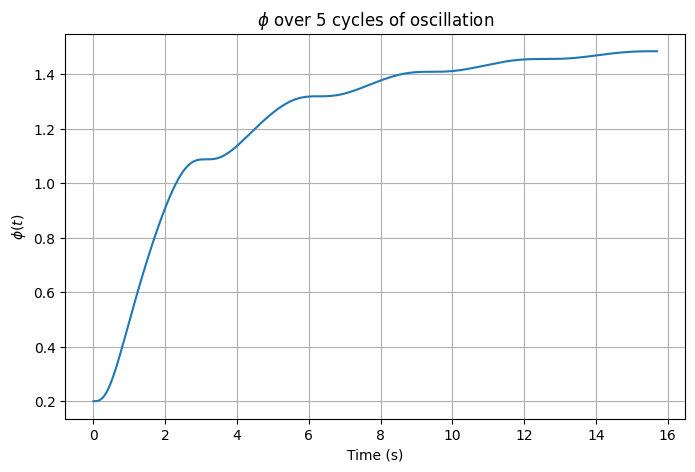

In [88]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

sp.init_printing()

# Time
t = sp.symbols('t', real=True)

# Parameters
m1, m2, w, g, omega = sp.symbols('m1 m2 w g omega', real=True)

# Configuration variables as a function of time
x = sp.Function('x')(t)
y = sp.Function('y')(t)
theta = sp.Function('theta')(t)
phi = sp.Function('phi')(t)
l = sp.Function('l')(t)

# Vectors of position, velocities, accelerations
q = sp.Matrix([x, y, theta, phi, l])
qd = q.diff(t)
qdd = q.diff(t, 2)

# Input torques
tau_phi = sp.sin(omega * t)
tau_l = sp.cos(omega * t)

Q = sp.Matrix([0, 0, 0, tau_phi, tau_l])

L = sp.simplify(T - V)

# Computing Euler-lagrange equations after redefining the input torques
EL_eqs = []
for i in range(len(q)):
    eq = sp.diff(sp.diff(L, qd[i]), t) - sp.diff(L, q[i]) - Q[i]
    EL_eqs.append(sp.simplify(eq))

EL_eqs = sp.Matrix(EL_eqs)

# Mass matrix and remaining terms
M = sp.simplify(EL_eqs.jacobian(qdd))
c = sp.simplify(EL_eqs - M * qdd)

# Replace time functions with simple symbols in order to use lambdify
x_s, y_s, theta_s, phi_s, l_s = sp.symbols('x_s y_s theta_s phi_s l_s', real=True)
xd_s, yd_s, thetad_s, phid_s, ld_s = sp.symbols('xd_s yd_s thetad_s phid_s ld_s', real=True)

subs_dict = {
    x: x_s,
    y: y_s,
    theta: theta_s,
    phi: phi_s,
    l: l_s,
    sp.diff(x, t): xd_s,
    sp.diff(y, t): yd_s,
    sp.diff(theta, t): thetad_s,
    sp.diff(phi, t): phid_s,
    sp.diff(l, t): ld_s
}

M_sub = sp.simplify(M.subs(subs_dict))
c_sub = sp.simplify(c.subs(subs_dict))

# Lambdify
vars_all = (
    t, x_s, y_s, theta_s, phi_s, l_s,
    xd_s, yd_s, thetad_s, phid_s, ld_s,
    m1, m2, w, g, omega
)

M_func = sp.lambdify(vars_all, M_sub, 'numpy')
c_func = sp.lambdify(vars_all, c_sub, 'numpy')

# Defining first-order ODE system
# state z = [x, y, theta, phi, l, xd, yd, thetad, phid, ld]
def hopper_ode(t_val, z, m1_val, m2_val, w_val, g_val, omega_val):
    x_val, y_val, theta_val, phi_val, l_val, xd_val, yd_val, thetad_val, phid_val, ld_val = z

    M_eval = np.array(M_func(
        t_val, x_val, y_val, theta_val, phi_val, l_val,
        xd_val, yd_val, thetad_val, phid_val, ld_val,
        m1_val, m2_val, w_val, g_val, omega_val
    ), dtype=float)

    c_eval = np.array(c_func(
        t_val, x_val, y_val, theta_val, phi_val, l_val,
        xd_val, yd_val, thetad_val, phid_val, ld_val,
        m1_val, m2_val, w_val, g_val, omega_val
    ), dtype=float).reshape(5,)

    # Solve Mqdd + c = 0
    qdd_val = np.linalg.solve(M_eval, -c_eval)

    return [
        xd_val,
        yd_val,
        thetad_val,
        phid_val,
        ld_val,
        qdd_val[0],
        qdd_val[1],
        qdd_val[2],
        qdd_val[3],
        qdd_val[4]
    ]

# Numerical values
m1_val = 1.0
m2_val = 0.5
w_val = 0.5
g_val = 9.81
omega_val = 2.0

# Initial conditions
z0 = [
    0.0,   # x(0)
    1.0,   # y(0)
    0.0,   # theta(0)
    0.2,   # phi(0)
    1.0,   # l(0)
    0.0,   # xdot(0)
    0.0,   # ydot(0)
    0.0,   # thetadot(0)
    0.0,   # phidot(0)
    0.0    # ldot(0)
]

# Simulate over 5 cycles
T_cycle = 2 * np.pi / omega_val
t_final = 5 * T_cycle
t_eval = np.linspace(0, t_final, 1000)

sol = solve_ivp(
    lambda t_val, z: hopper_ode(t_val, z, m1_val, m2_val, w_val, g_val, omega_val),
    [0, t_final],
    z0,
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-8
)

plt.figure(figsize=(8, 5))
plt.plot(sol.t, sol.y[3])
plt.xlabel('Time (s)')
plt.ylabel(r'$\phi(t)$')
plt.title(r'$\phi$ over 5 cycles of oscillation')
plt.grid(True)
plt.show()